# **R/S BENCHMARK — SPAGHETTI PLOT & RUL ANALYSIS**

Loads the $(R, S)$-fixed, time-swept GLD samples written by
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) and:

1. draws the spaghetti plot of $g(t)$ (every Monte Carlo path, plus the mean);
2. turns each path into a failure time (`compute_rul_benchmark`, the first down-crossing of
   `threshold`, right-censored at the last time step if it never crosses) and reports the RUL
   distribution;
3. compares the $g$ distribution at a few chosen time steps; and
4. computes the **conditional** RUL given survival to a chosen time.

No emulator or NN calls here — this notebook only reads the `.pkl` written by stage 5 and plots.
Same figure conventions as [`01_plot_lambda_maps.ipynb`](01_plot_lambda_maps.ipynb): separate
figures, no titles (captions belong in the LaTeX), configurable size/fonts/dpi, each saved next to
the data it came from.

## 1. Libraries

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import dill

from functions import compute_rul_benchmark

## 2. Config

`n_latent_samples`, `r_fixed` and `s_fixed` must match
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) — together they name the file
being loaded.

`threshold` is the failure level on $g$ (failure is $g \le$ `threshold`).

In [5]:
n_latent_samples = 2500   # must match stage 5 — it names the file being loaded
r_fixed = 5.0             # must match stage 5
s_fixed = 2.0             # must match stage 5

threshold = 0.0   # failure is g <= threshold

fig_size   = (6, 4.5)    # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (0, 150) to fix the time axis; None = auto-scaled to the data
ylim = None   # e.g. (-15, 15) to fix the g axis; None = auto-scaled to the data

n_paths_plotted = 300   # spaghetti lines drawn (all n_glam_samples would be far too many to render)
random_state    = 42

## 3. Load the RUL dataset

In [6]:
tag      = f'R{r_fixed:g}_S{s_fixed:g}_benchmark'
pkl_name = f'{n_latent_samples}_rul_samples_{tag}'

with open(f'{n_latent_samples}_rul_lambdas_{tag}.pkl', 'rb') as f:
    lambda_df = dill.load(f)
with open(f'{pkl_name}.pkl', 'rb') as f:
    samples = dill.load(f)

times = lambda_df['Time (years)'].to_numpy()
print(f"Loaded samples: {samples.shape[0]} paths x {samples.shape[1]} time steps")
lambda_df

Loaded samples: 10000 paths x 16 time steps


,r,s,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,5.0,2.0,0.0,3.003417,6.135591,0.134146,0.128459
1,5.0,2.0,10.0,2.658036,6.238472,0.134146,0.128459
2,5.0,2.0,20.0,2.310753,6.328487,0.134146,0.128459
3,5.0,2.0,30.0,1.952825,6.692838,0.134146,0.128459
4,5.0,2.0,40.0,1.601684,6.916609,0.134146,0.128459
5,5.0,2.0,50.0,1.262719,7.099942,0.134146,0.128459
6,5.0,2.0,60.0,0.911773,7.082962,0.134146,0.128459
7,5.0,2.0,70.0,0.564519,7.160044,0.134146,0.128459
8,5.0,2.0,80.0,0.200263,7.749033,0.134146,0.128459
9,5.0,2.0,90.0,-0.153479,7.798964,0.134146,0.128459


## 4. Spaghetti plot

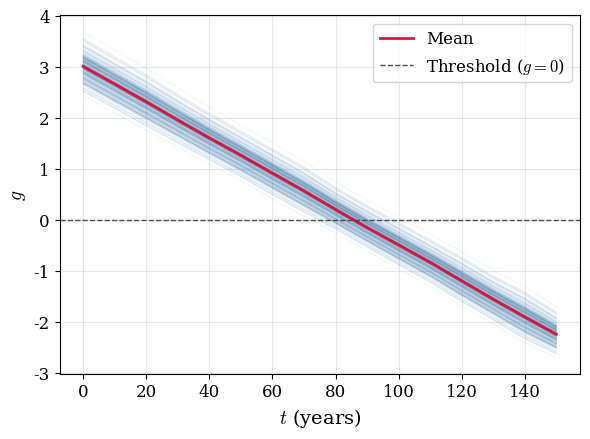

In [7]:
rng           = np.random.default_rng(random_state)
plotted_idx   = rng.choice(samples.shape[0], size=min(n_paths_plotted, samples.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=fig_size)
for i in plotted_idx:
    ax.plot(times, samples[i], color='steelblue', alpha=0.08, linewidth=0.6)
ax.plot(times, samples.mean(axis=0), color='crimson', linewidth=2, label='Mean')
ax.axhline(threshold, color='0.3', linestyle='--', linewidth=1, label=f'Threshold ($g={threshold:g}$)')

ax.set_xlabel('$t$ (years)', fontsize=label_fontsize)
ax.set_ylabel('$g$', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_spaghetti.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 5. RUL — time to failure

`compute_rul_benchmark` finds, for every Monte Carlo path, the first time $g$ drops to or below
`threshold` (linear interpolation between the two straddling time steps). A path that never crosses
is right-censored at `times[-1]` — check `n_censored` below before trusting the tail of the
distribution: heavy censoring means the time grid in stage 5 didn't reach far enough.

In [8]:
failure_times = compute_rul_benchmark(samples, times, threshold=threshold)
n_censored    = int(np.sum(failure_times == times[-1]))

print(f"Failure times: {len(failure_times)} paths ({n_censored} right-censored at t={times[-1]:.1f})")
print(f"  Mean:   {failure_times.mean():.2f}")
print(f"  Median: {np.median(failure_times):.2f}")
print(f"  Std:    {failure_times.std():.2f}")
print(f"  P5:     {np.percentile(failure_times, 5):.2f}")
print(f"  P95:    {np.percentile(failure_times, 95):.2f}")

Failure times: 10000 paths (0 right-censored at t=150.0)
  Mean:   85.69
  Median: 85.67
  Std:    5.42
  P5:     76.76
  P95:    94.74


### 5.1 RUL probability density

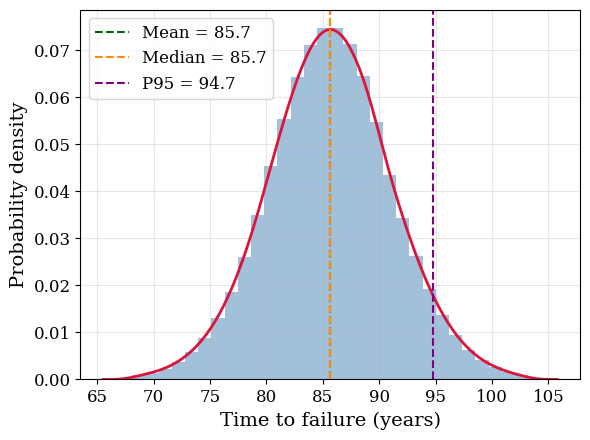

In [9]:
fig, ax = plt.subplots(figsize=fig_size)
ax.hist(failure_times, bins=30, density=True, alpha=0.5, color='steelblue')
sns.kdeplot(failure_times, ax=ax, color='crimson', linewidth=2)

for value, label, color in [(failure_times.mean(), 'Mean', 'darkgreen'),
                             (np.median(failure_times), 'Median', 'darkorange'),
                             (np.percentile(failure_times, 95), 'P95', 'purple')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

ax.set_xlabel('Time to failure (years)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_rul_pdf.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 6. $g$ distribution at a few time steps

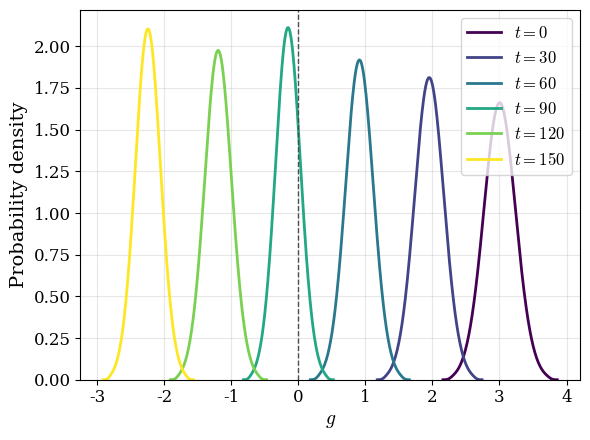

In [10]:
time_indices = np.linspace(0, len(times) - 1, min(6, len(times)), dtype=int)

fig, ax = plt.subplots(figsize=fig_size)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for idx, color in zip(time_indices, colors):
    sns.kdeplot(samples[:, idx], ax=ax, color=color, linewidth=2, label=f'$t={times[idx]:.0f}$')

ax.axvline(threshold, color='0.3', linestyle='--', linewidth=1)
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_g_pdfs.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 7. Conditional RUL — given survival to a chosen time

Restricts to paths that are still above `threshold` at `time_query`, and reports **RUL from
`time_query`** (not from $t=0$) for those survivors: $\mathrm{RUL} = t_{\text{failure}} -
\text{time\_query}$.

Survivors at t=50.0: 10000 / 10000


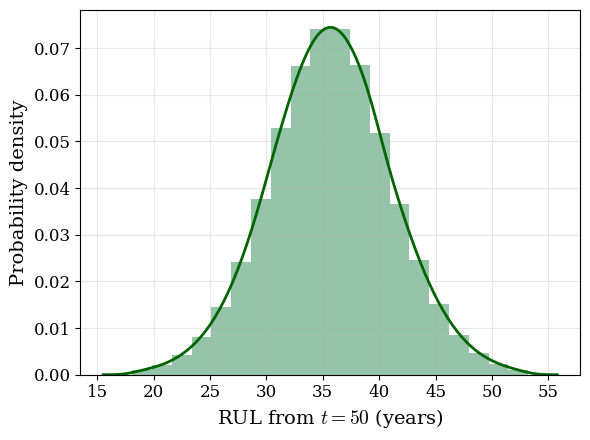


Conditional RUL from t=50.0:
  Mean:   35.69
  Median: 35.67
  P95:    44.74


In [11]:
time_query = 50.0   # condition on survival up to this time

idx_query      = int(np.argmin(np.abs(times - time_query)))
survivors_mask = samples[:, idx_query] > threshold
print(f"Survivors at t={times[idx_query]:.1f}: {survivors_mask.sum()} / {len(survivors_mask)}")

if survivors_mask.sum() == 0:
    print("No surviving paths at this time — pick an earlier time_query.")
else:
    failure_times_survivors = compute_rul_benchmark(samples[survivors_mask], times, threshold=threshold)
    conditional_rul = failure_times_survivors[failure_times_survivors > times[idx_query]] - times[idx_query]

    fig, ax = plt.subplots(figsize=fig_size)
    ax.hist(conditional_rul, bins=20, density=True, alpha=0.5, color='seagreen')
    sns.kdeplot(conditional_rul, ax=ax, color='darkgreen', linewidth=2)

    ax.set_xlabel(f'RUL from $t={times[idx_query]:.0f}$ (years)', fontsize=label_fontsize)
    ax.set_ylabel('Probability density', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_conditional_rul_t{times[idx_query]:.0f}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    plt.show()

    print(f"\nConditional RUL from t={times[idx_query]:.1f}:")
    print(f"  Mean:   {conditional_rul.mean():.2f}")
    print(f"  Median: {np.median(conditional_rul):.2f}")
    print(f"  P95:    {np.percentile(conditional_rul, 95):.2f}")